In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
from tqdm import tqdm

import tidy3d as td
import tidy3d.web as web
import gdstk

import gdsfactory as gf
from DirectionalCoupler_GF import DirectionalCoupler

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory
import addcopyfighandler

WORKDIR   = Path().resolve()
REPO_ROOT = WORKDIR.parents[1]
os.chdir(WORKDIR)

data_save_dir = REPO_ROOT / "results_data" / "Data_directional_coupler_tidy3d"
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WORKDIR)
print("Data save   :", data_save_dir)

Working dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts\directional_coupler
Data save   : D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_directional_coupler_tidy3d


In [2]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart    = 1540e-9
LambdaStop     = 1560e-9

Height         = 800e-9
XLength        = 20e-6
YLength        = 12e-6

Index_core     = 1.97
Index_clad     = 1.445

SimulationTime = 5e-12
FrequencyPoints = 40

Height_um = Height * 1e6

# Frequency
freq_center = td.C_0 / (1550 * 1e6)
fwidth      = td.C_0 / (10)
freq_start  = td.C_0 / (LambdaStop * 1e6)
freq_stop   = td.C_0 / (LambdaStart * 1e6)

#------------------------------------------------------------
# MATERIALS
#------------------------------------------------------------
mat_core = td.Medium(permittivity=Index_core**2)
mat_clad = td.Medium(permittivity=Index_clad**2)

#------------------------------------------------------------
# SWEEP LISTS
#------------------------------------------------------------
Widths          = np.array([1200]) * 1e-9
ArcRadii        = np.array([20]) * 1e-6
CouplingLengths = np.array([12]) * 1e-6
Gaps            = np.array([300, 600]) * 1e-9
Eulers          = [1]


# Debug cell

In [3]:

# #------------------------------------------------------------
# # GDS GENERATION (test single geometry)
# #------------------------------------------------------------
# gf.clear_cache()
# dc = DirectionalCoupler(
#     InLengthX=XLength * 1e6,
#     LengthY=YLength * 1e6,
#     CouplingLengthX=CouplingLengths[0] * 1e6,
#     WgWidth=Widths[0] * 1e6,
#     Radius=ArcRadii[0] * 1e6,
#     Gap=Gaps[0] * 1e6,
#     Euler=Eulers[0],
#     Layer=(2, 0),
# )

# gds_path = str(WORKDIR / "DC_tidy3d_test.gds")
# # dc.write_gds(gds_path)
# dc_flat = dc.copy()
# dc_flat.flatten()
# dc_flat.write_gds(gds_path)

#------------------------------------------------------------
# GDS → tidy3d structures
#------------------------------------------------------------


# lib = gdstk.read_gds(gds_path)
# top_cell = lib.top_level()[0]

# geo = td.Geometry.from_gds(
#     top_cell,
#     gds_layer=2,
#     gds_dtype=0,
#     axis=2,
#     slab_bounds=(0, Height * 1e6),  # m → µm
# )

# structs = [td.Structure(geometry=geo, medium=mat_core)]
# print(f"Imported {len(structs)} structure(s)")

# # Verify ports
# for p in dc.ports:
#     print(f"  {p.name}: center=({p.dcenter[0]:.2f}, {p.dcenter[1]:.2f}) µm, orientation={p.orientation}°")

# Simulation Setup

Structure type: <class 'tidy3d.components.geometry.base.GeometryGroup'>
  o1: (-66.00, -52.75) µm, orientation=180.0°
  o2: (66.00, -52.75) µm, orientation=0.0°
  o3: (-66.00, 52.75) µm, orientation=180.0°
  o4: (66.00, 52.75) µm, orientation=0.0°
Ports:
  o1: (-66.00, -52.75) µm
  o2: (66.00, -52.75) µm
  o3: (-66.00, 52.75) µm
  o4: (66.00, 52.75) µm
Sim center: (0, 0, 0.3999999999999999)
Sim size:   (119.6, 109.8, 2.8)
Source x: -44.80, TH x: 44.80, CR x: 44.80


20:30:16 Eastern Daylight Time WARNING: Structure at structures[0] was detected 
                               as being less than half of a central wavelength  
                               from a PML on side y-min. To avoid inaccurate    
                               results or divergence, please increase gap       
                               between any structures and PML or fully extend   
                               structure through the pml.                       

                               WARNING: Suppressed 3 WARNING messages.          

                               WARNING: 'monitors[0]' contains frequencies      
                               outside of the simulation frequency range (0e+00,
                               1e+14)(Hz) as defined by the sources.            

                               WARNING: Suppressed 1 WARNING message.           

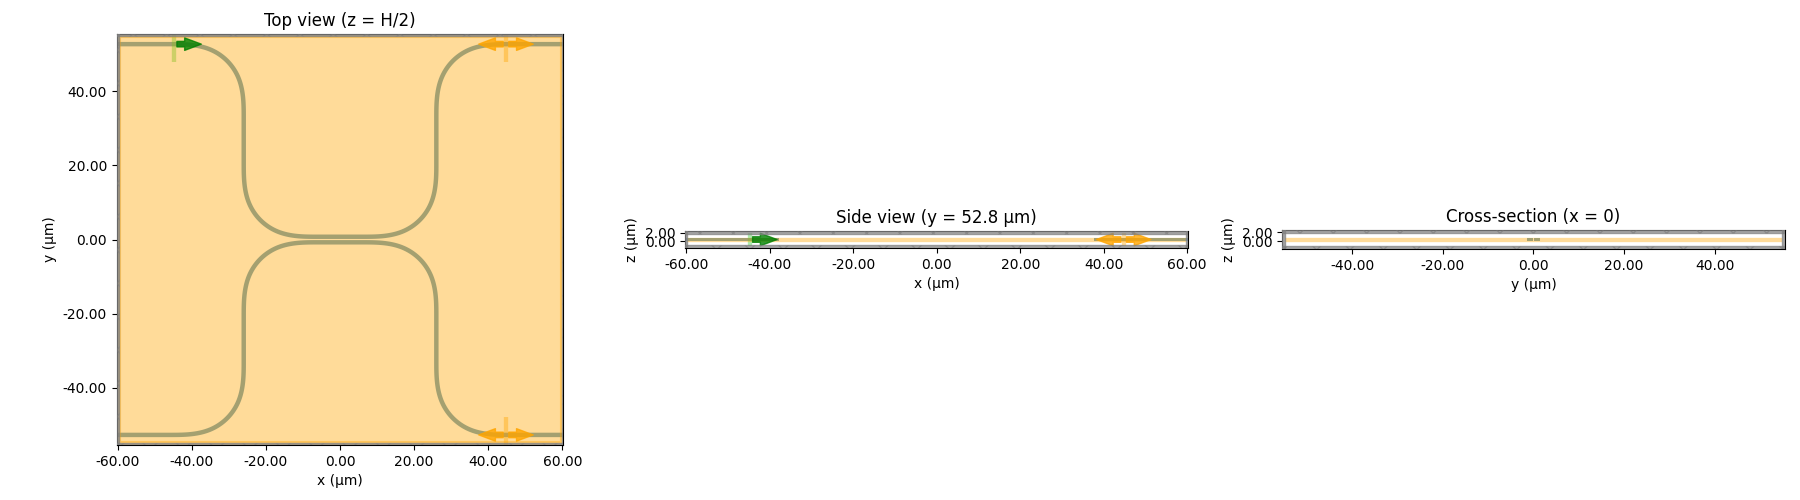

In [4]:
#------------------------------------------------------------
# SINGLE TEST — no loop
#------------------------------------------------------------
ArcRadius      = 20e-6
Width          = 1200e-9
CouplingLength = 12e-6
Gap            = 300e-9
Euler          = 1

#------------------------------------------------------------
# GDS
#------------------------------------------------------------
gf.clear_cache()
dc = DirectionalCoupler(
    InLengthX=XLength * 1e6,
    LengthY=YLength * 1e6,
    CouplingLengthX=CouplingLength * 1e6,
    WgWidth=Width * 1e6,
    Radius=ArcRadius * 1e6,
    Gap=Gap * 1e6,
    Euler=Euler,
    Layer=(2, 0),
)

# Write flat GDS
dc_flat = dc.copy()
dc_flat.flatten()
gds_path = str(WORKDIR / "DC_tidy3d_test.gds")
dc_flat.write_gds(gds_path)

# Import into tidy3d
lib = gdstk.read_gds(gds_path)
top_cell = lib.top_level()[0]

geo = td.Geometry.from_gds(
    top_cell,
    gds_layer=2,
    gds_dtype=0,
    axis=2,
    slab_bounds=(0, Height_um),
)
wg_struct = td.Structure(geometry=geo, medium=mat_core)

print(f"Structure type: {type(geo)}")

# Verify ports (from original dc, not dc_flat)
for p in dc.ports:
    print(f"  {p.name}: ({p.dcenter[0]:.2f}, {p.dcenter[1]:.2f}) µm, orientation={p.orientation}°")
#------------------------------------------------------------
# BBOX & PORTS (µm)
#------------------------------------------------------------

bbox = dc.bbox()
margin = (LambdaStop + LambdaStart) / 2 * 1e6  # m → µm
offset = 15.0  # µm

ports = {p.name: (p.dcenter[0], p.dcenter[1]) for p in dc.ports}  # already µm

x_span = (bbox.right - bbox.left) - 8 * margin
y_span = (bbox.top - bbox.bottom) + 2 * margin

SourcePosX = -(x_span / 2) + offset
TH_PosX    =  (x_span / 2) - offset
CR_PosX    = TH_PosX

z_min_um = -1.0
z_max_um = Height_um + 1.0

sim_center = (0, 0, (z_min_um + z_max_um) / 2)
sim_size   = (x_span, y_span, z_max_um - z_min_um)

print(f"Ports:")
for name, pos in ports.items():
    print(f"  {name}: ({pos[0]:.2f}, {pos[1]:.2f}) µm")
print(f"Sim center: {sim_center}")
print(f"Sim size:   {sim_size}")
print(f"Source x: {SourcePosX:.2f}, TH x: {TH_PosX:.2f}, CR x: {CR_PosX:.2f}")

#------------------------------------------------------------
# SOURCE
#------------------------------------------------------------
neff_target = 1.86  # from effective index calculation

source = td.ModeSource(
    center=(SourcePosX, ports["o3"][1], Height_um / 2),
    size=(0, 8 * Width * 1e6, 4 * Height_um),
    source_time=td.GaussianPulse(freq0=freq_center, fwidth=fwidth),
    direction="+",
    mode_spec=td.ModeSpec(num_modes=1, target_neff=neff_target),
    name="ModeSource",
)

#------------------------------------------------------------
# MONITORS
#------------------------------------------------------------
mon_through = td.ModeMonitor(
    center=(TH_PosX, ports["o4"][1], Height_um / 2),
    size=(0, 8 * Width * 1e6, 4 * Height_um),
    freqs=np.linspace(freq_start, freq_stop, FrequencyPoints),
    mode_spec=td.ModeSpec(num_modes=1, target_neff=neff_target),
    name="TH",
)

mon_cross = td.ModeMonitor(
    center=(CR_PosX, ports["o2"][1], Height_um / 2),
    size=(0, 8 * Width * 1e6, 4 * Height_um),
    freqs=np.linspace(freq_start, freq_stop, FrequencyPoints),
    mode_spec=td.ModeSpec(num_modes=1, target_neff=neff_target),
    name="CR",
)

mon_field = td.FieldMonitor(
    center=(0, 0, Height_um / 2),
    size=(sim_size[0], sim_size[1], 0),
    freqs=[freq_center],
    name="FieldMonitor",
)

#------------------------------------------------------------
# SIMULATION
#------------------------------------------------------------
sim = td.Simulation(
    center=sim_center,
    size=sim_size,
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=20, wavelength=1.55),
    structures=[wg_struct],
    sources=[source],
    monitors=[mon_through, mon_cross, mon_field],
    run_time=SimulationTime,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    medium=mat_clad,
)

#------------------------------------------------------------
# VISUALIZE — check before running
#------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sim.plot(z=Height_um / 2, ax=axes[0])
axes[0].set_title("Top view (z = H/2)")

sim.plot(y=ports["o3"][1], ax=axes[1])
axes[1].set_title(f"Side view (y = {ports['o3'][1]:.1f} µm)")

sim.plot(x=0, ax=axes[2])
axes[2].set_title("Cross-section (x = 0)")

plt.tight_layout()
# sim.plot_3d()

                               WARNING: Use the remote mode solver with subpixel
                               averaging for better accuracy through            
                               'tidy3d.web.run(...)' or the deprecated          
                               'tidy3d.plugins.mode.web.run(...)'.              

c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.py:42: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Ny, Ny)))
c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.py:55: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Ny, Ny)))
c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.p

Output()

c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.py:42: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Ny, Ny)))
c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.py:55: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Ny, Ny)))


20:30:18 Eastern Daylight Time WARNING: Did not finish enforcing passivity in   
                               dispersion fitter. If the fit is not good enough,
                               consider increasing                              
                               'AdvancedFastFitterParam.passivity_num_iters'.   

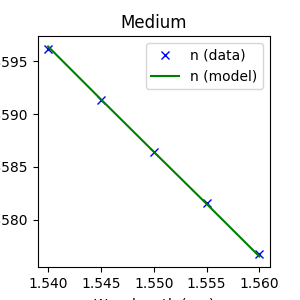

c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.py:42: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Ny, Ny)))
c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.py:55: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Ny, Ny)))
c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.p

Output()

c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.py:42: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Ny, Ny)))
c:\Users\smmit\miniconda3\envs\DL_ML_env\Lib\site-packages\tidy3d\components\mode\derivatives.py:55: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Ny, Ny)))


20:30:22 Eastern Daylight Time WARNING: Did not finish enforcing passivity in   
                               dispersion fitter. If the fit is not good enough,
                               consider increasing                              
                               'AdvancedFastFitterParam.passivity_num_iters'.   

20:30:28 Eastern Daylight Time WARNING: Unable to fit with weighted RMS error   
                               under 'tolerance_rms' of 1e-05                   

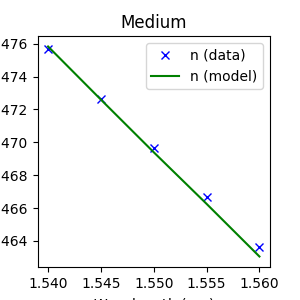

                               WARNING: Structure at 'structures[0]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Structure at structures[0] was detected 
                               as being less than half of a central wavelength  
                               from a PML on side y-min. To avoid inaccurate    
                               results or divergence, please increase gap       
                               between any structures and PML or fully extend   
                               structure through the pml.                       

                               WARNING: Suppressed 1 WARNING message.           

                               WARNING: 'monitors[0]' contains frequencies      
                               outside of the simulation frequency range (0e+00,
                               1e+14)(Hz) as defined by the sources.            

                               WARNING: Suppressed 1 WARNING message.           

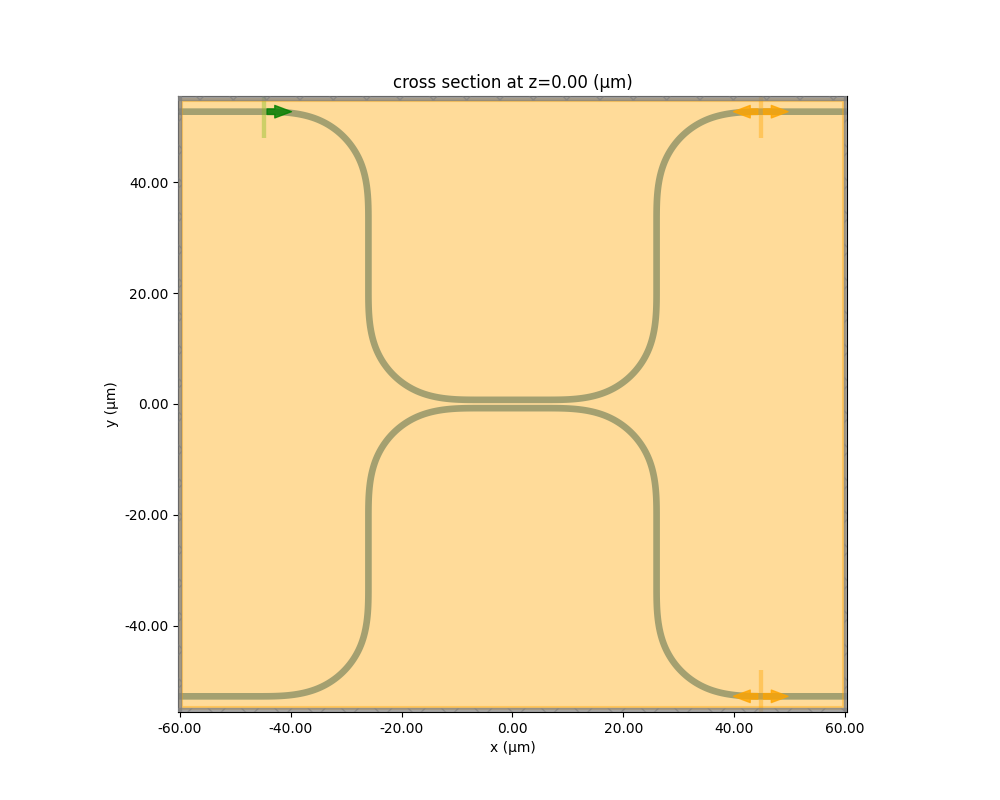

In [5]:
from tidy3d_effective2D_helpers import approximate_material, create_2D_sim
import logging
logging.getLogger("tidy3d").setLevel(logging.ERROR)

# Reference point: straight waveguide section (input arm)
ref_point = (SourcePosX, ports["o3"][1])
core_point = ref_point
clad_point = (0, 0)

spectrum = np.linspace(1.54, 1.56, 5)

med_core_eff = approximate_material(sim, core_point, ref_point, spectrum, plot=True)
med_clad_eff = approximate_material(sim, clad_point, ref_point, spectrum, plot=True)

logging.getLogger("tidy3d").setLevel(logging.WARNING)

# Convert to 2D
sim_2d = create_2D_sim(sim, [med_core_eff, med_clad_eff])

# Verify
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sim_2d.plot(z=0, ax=ax)
ax.set_aspect('equal')
plt.show()

In [6]:
task_id = web.upload(sim_2d, task_name="DC_test_check")
print(f"View at: https://tidy3d.simulation.cloud/workbench?taskId={task_id}")

                               Created task 'DC_test_check' with task_id        
                               'fdve-36cabeb6-6cab-47e6-b641-d92fa9fc90a9' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=214645;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36cabeb6-6cab-47e6-b641-d92fa9fc90a9\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=532352;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36cabeb6-6cab-47e6-b641-d92fa9fc90a9\taskId]8;;\
                               ]8;id=214645;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36cabeb6-6cab-47e6-b641-d92fa9fc90a9\=]8;;\]8;id=949291;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36cabeb6-6cab-47e6-b641-d92fa9fc90a9\fdve]8;;\]8;id=214645;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36cabeb6-6cab-47e6-b641-d92fa9fc90a9\-36cabeb6-6cab-47e6-b641-d92fa9fc90a9']8;;\.

                               Task folder: ]8;id=592605;https://tidy3d.simulation.cloud/folders/folder-e2697c97-55bb-47aa-9f90-36eef282740e\'default']8;;\.

Output()

20:30:30 Eastern Daylight Time Maximum FlexCredit cost: 0.459. Minimum cost     
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

View at: https://tidy3d.simulation.cloud/workbench?taskId=fdve-36cabeb6-6cab-47e6-b641-d92fa9fc90a9


In [7]:
#------------------------------------------------------------
# RUN 2D
#------------------------------------------------------------
sim_data_2d = web.run(sim_2d, task_name="DC_2D_test", path=str(data_save_dir / "DC_2D_test.hdf5"))


                               Created task 'DC_2D_test' with task_id           
                               'fdve-f9eaf008-b117-4935-be6b-c58635ac3081' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=768544;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f9eaf008-b117-4935-be6b-c58635ac3081\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=19045;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f9eaf008-b117-4935-be6b-c58635ac3081\taskId]8;;\
                               ]8;id=768544;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f9eaf008-b117-4935-be6b-c58635ac3081\=]8;;\]8;id=179663;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f9eaf008-b117-4935-be6b-c58635ac3081\fdve]8;;\]8;id=768544;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f9eaf008-b117-4935-be6b-c58635ac3081\-f9eaf008-b117-4935-be6b-c58635ac3081']8;;\.

                               Task folder: ]8;id=141256;https://tidy3d.simulation.cloud/folders/folder-e2697c97-55bb-47aa-9f90-36eef282740e\'default']8;;\.

Output()

20:30:31 Eastern Daylight Time Maximum FlexCredit cost: 0.459. Minimum cost     
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

...

                               WARNING: Structure at structures[0] was detected 
                               as being less than half of a central wavelength  
                               from a PML on side y-min. To avoid inaccurate    
                               results or divergence, please increase gap       
                               between any structures and PML or fully extend   
                               structure through the pml.                       

                               WARNING: Suppressed 1 WARNING message.           

                               WARNING: 'monitors[0]' contains frequencies      
                               outside of the simulation frequency range (0e+00,
                               1e+14)(Hz) as defined by the sources.            

                               WARNING: Suppressed 1 WARNING message.           

                               WARNING: Warning messages were found in the      
                               solver log. For more information, check          
                               'SimulationData.log' or use                      
                               'web.download_log(task_id)'.                     

κ² = 0.0016 (0.16%)
Loss = 54.51 dB


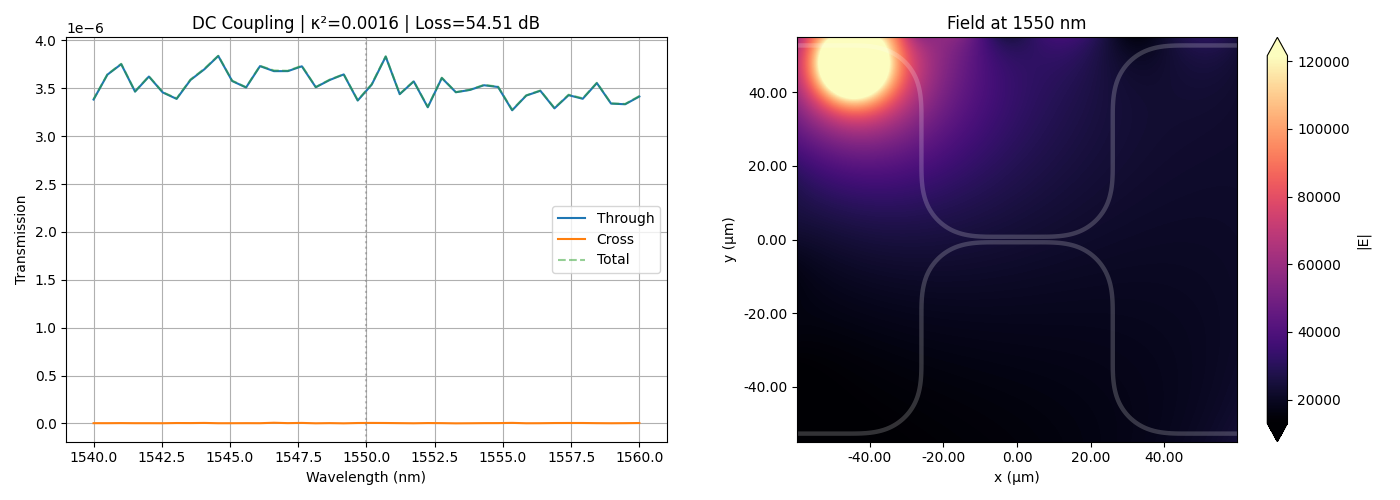

In [8]:

#------------------------------------------------------------
# EXTRACT RESULTS
#------------------------------------------------------------
th_amps = sim_data_2d["TH"].amps.sel(mode_index=0, direction="+")
cr_amps = sim_data_2d["CR"].amps.sel(mode_index=0, direction="+")

Tx_Through = np.abs(th_amps.values.flatten()) ** 2
Tx_Cross   = np.abs(cr_amps.values.flatten()) ** 2

freqs_mon = th_amps.f.values
Wavelength = td.C_0 / freqs_mon * 1e-6  # µm → m


Tx_total = Tx_Through + Tx_Cross

idx_1550       = np.argmin(np.abs(Wavelength - 1550e-9))
kappa_sq_1550  = Tx_Cross[idx_1550] / (Tx_Cross[idx_1550] + Tx_Through[idx_1550])
loss_dB_1550   = -10 * np.log10(Tx_total[idx_1550])

print(f"κ² = {kappa_sq_1550:.4f} ({kappa_sq_1550*100:.2f}%)")
print(f"Loss = {loss_dB_1550:.2f} dB")

#------------------------------------------------------------
# PLOT: Through & Cross vs Wavelength
#------------------------------------------------------------
Wavelength_nm = Wavelength * 1e9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(Wavelength_nm, Tx_Through, '-', label='Through')
ax1.plot(Wavelength_nm, Tx_Cross, '-', label='Cross')
ax1.plot(Wavelength_nm, Tx_total, '--', label='Total', alpha=0.5)
ax1.axvline(1550, color='gray', ls=':', alpha=0.5)
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Transmission')
ax1.set_title(f'DC Coupling | κ²={kappa_sq_1550:.4f} | Loss={loss_dB_1550:.2f} dB')
ax1.legend()
ax1.grid()

#------------------------------------------------------------
# PLOT: Field Monitor
#------------------------------------------------------------
sim_data_2d.plot_field("FieldMonitor", "E", "abs", z=0, ax=ax2)
ax2.set_title("Field at 1550 nm")

plt.tight_layout()
plt.savefig(data_save_dir / f"DC_2D_tidy3d_R{ArcRadius*1e6:.0f}_W{Width*1e9:.0f}_CL{CouplingLength*1e6:.0f}_G{Gap*1e9:.0f}.png",
            dpi=150, bbox_inches='tight')
plt.show()

Core eff eps: (3.454554443469194+2.1259281896761177e-06j)
Clad eff eps: (1.8142461202387794-4.89039302114785e-07j)
Source size: (0.0, 9.6, 3.1999999999999997)
Source center: (-44.8, 52.75, 0.0)


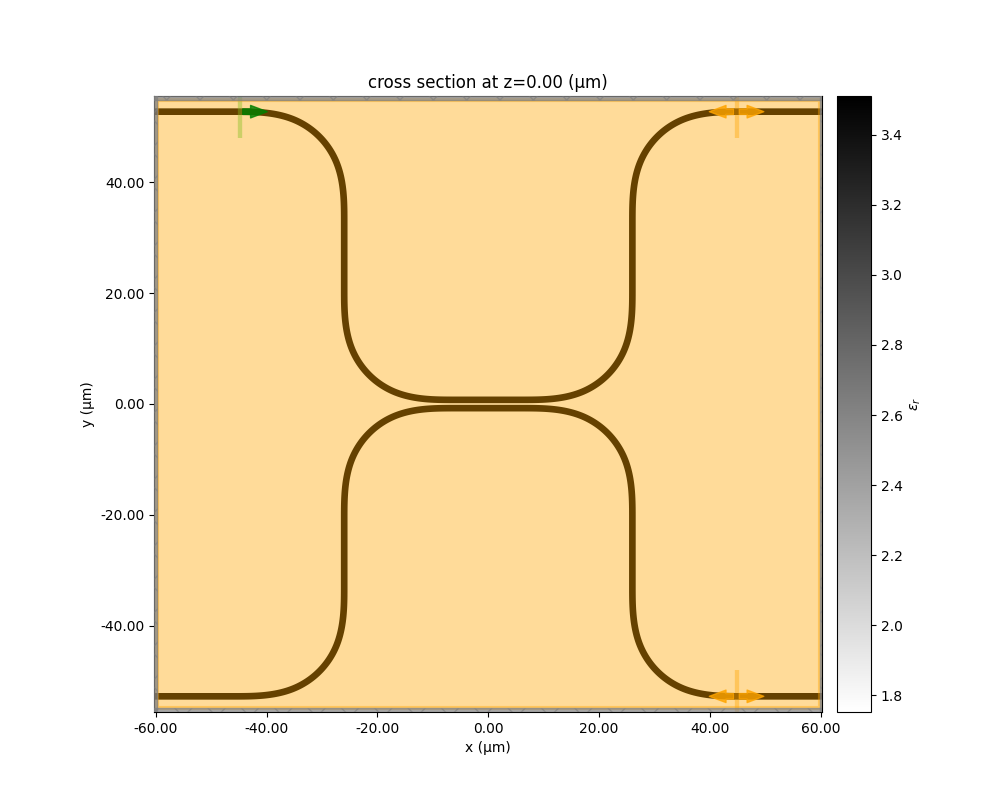

In [9]:
# 1. Check effective permittivities
print(f"Core eff eps: {med_core_eff.eps_model(td.C_0/1.55)}")
print(f"Clad eff eps: {med_clad_eff.eps_model(td.C_0/1.55)}")

# 2. Check source mode
print(f"Source size: {sim_2d.sources[0].size}")
print(f"Source center: {sim_2d.sources[0].center}")

# 3. Visualize the 2D sim permittivity
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sim_2d.plot_eps(z=0, ax=ax)
ax.set_aspect('equal')
plt.show()

In [10]:
print(f"Source x: {sim_2d.sources[0].center[0]:.2f}")
print(f"Sim x_min: {sim_2d.center[0] - sim_2d.size[0]/2:.2f}")
print(f"PML layers: {sim_2d.boundary_spec.x}")

Source x: -44.80
Sim x_min: -59.80
PML layers: attrs={} plus=PML(attrs={}, name=None, type='PML', num_layers=12, parameters=PMLParams(attrs={}, sigma_order=3, sigma_min=0.0, sigma_max=1.5, type='PMLParams', kappa_order=3, kappa_min=1.0, kappa_max=3.0, alpha_order=1, alpha_min=0.0, alpha_max=0.0)) minus=PML(attrs={}, name=None, type='PML', num_layers=12, parameters=PMLParams(attrs={}, sigma_order=3, sigma_min=0.0, sigma_max=1.5, type='PMLParams', kappa_order=3, kappa_min=1.0, kappa_max=3.0, alpha_order=1, alpha_min=0.0, alpha_max=0.0)) type='Boundary'
